# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [19]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE
current_working_directory = os.getcwd()
print("=== Environment Setup ===")
print(f"Current Working Directory: {current_working_directory}")

files_in_directory = os.listdir(current_working_directory)
print(f"Files in Project Directory: {files_in_directory}\n")
# 2. Acquire and load your primary dataset
# YOUR CODE HERE
data_path_primary = "../data/hw/hw_3/keishu-kanazawa/GDPPCgrowth-USD-countries.csv" 
gdpg_raw = pd.read_csv(data_path_primary, skiprows=2)
gdpg_raw.head()

 # Update with your actual path

=== Environment Setup ===
Current Working Directory: c:\Users\keish\OneDrive\ドキュメント\東大授業関係\5S\Data Science for Public Policy\datascience-publicpolicy-2026\notebooks\hw\hw_3
Files in Project Directory: ['hw_3.ipynb']



,CountryID,Country,1971,1972,1973,1974,1975,1976,1977,1978,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,4,Afghanistan,-2.7,-18.4,0.3,2.8,3.7,3.2,-7.0,5.3,...,-5.5,0.2,-1.1,-1.1,7.5,-5.1,-22.6,-7.6,0.1,-1.1
1,8,Albania,1.5,1.5,1.6,1.6,1.7,1.7,1.6,2.0,...,2.4,3.9,3.3,3.8,2.4,-2.9,9.8,5.6,4.6,4.8
2,12,Algeria,-11.5,19.5,1.9,1.3,2.1,1.5,5.5,7.1,...,1.1,1.8,-0.5,-0.5,-0.9,-6.6,2.1,2.0,2.5,2.2
3,20,Andorra,-2.5,1.0,0.9,-0.9,-5.4,-2.5,-2.7,-3.6,...,3.6,3.7,-1.8,-0.3,0.3,-12.2,6.9,7.7,1.1,2.0
4,24,Angola,3.6,-2.8,4.5,-0.4,-8.2,-8.3,-2.5,-8.5,...,-2.8,-5.2,-3.6,-4.0,-3.5,-7.1,-1.1,1.0,-1.8,1.3


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*

In [ ]:
#primarydata: UN national accounts, GDP per capita growth in USD, by country, 2024
#secondarydata: Polity V, polity2 score by country and year, 2018

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [28]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
print("=== Reshaping Data ===")


gdpg_long = pd.melt(
    gdpg_raw, 
    id_vars=['CountryID', 'Country'], 
    var_name='year_str',                    
    value_name='gdp_growth'                 
)

gdpg_long['year'] = gdpg_long['year_str'].str.replace('gdp_growth_', '').astype(int)

gdpg_long = gdpg_long.drop(columns=['year_str'])
gdpg_long = gdpg_long[['CountryID', 'Country', 'year', 'gdp_growth']]

gdpg_long = gdpg_long.sort_values(by=['Country', 'year']).reset_index(drop=True)

print("--- Reshaped Data (Long Format) ---")
print(gdpg_long.head(10))
print(f"\nNew Shape: {gdpg_long.shape}")
print("=== Data Inspection ===")


=== Reshaping Data ===
--- Reshaped Data (Long Format) ---
   CountryID      Country  year  gdp_growth
0          4  Afghanistan  1971        -2.7
1          4  Afghanistan  1972       -18.4
2          4  Afghanistan  1973         0.3
3          4  Afghanistan  1974         2.8
4          4  Afghanistan  1975         3.7
5          4  Afghanistan  1976         3.2
6          4  Afghanistan  1977        -7.0
7          4  Afghanistan  1978         5.3
8          4  Afghanistan  1979        -2.9
9          4  Afghanistan  1980        -0.2

New Shape: (11880, 4)
=== Data Inspection ===


In [35]:
# 2. Rename columns and select a clean subset
#  YOUR CODE HERE
gdpg_long.rename(columns={'Country': 'country'}, inplace=True)
cols_gdpg = ['country', 'year', 'gdp_growth']
gdpg = gdpg_long[cols_gdpg]
gdpg.head(5)

,country,year,gdp_growth
0,Afghanistan,1971,-2.7
1,Afghanistan,1972,-18.4
2,Afghanistan,1973,0.3
3,Afghanistan,1974,2.8
4,Afghanistan,1975,3.7


In [ ]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE

In [ ]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [39]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
print("=== Loading Secondary Dataset ===")
data_path_secondary = "../data/hw/hw_3/keishu-kanazawa/p5v2018.csv"
p5v_raw = pd.read_csv(data_path_secondary)

print("=== Selecting Columns from Polity V ===")
cols_p5v = ['country', 'year', 'polity2']
p5v = p5v_raw[cols_p5v]
p5v.head(5)

=== Loading Secondary Dataset ===
=== Selecting Columns from Polity V ===


,country,year,polity2
0,Afghanistan,1800,-6.0
1,Afghanistan,1801,-6.0
2,Afghanistan,1802,-6.0
3,Afghanistan,1803,-6.0
4,Afghanistan,1804,-6.0


In [44]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
print("=== Merging Datasets ===")
merged_data = pd.merge(gdpg, p5v, on=['country', 'year'], how='inner')

print("=== Filtering Valid Polity Scores ===")
valid_polity_mask = (merged_data['polity2'] >= -10) & (merged_data['polity2'] <= 10)
filtered_data = merged_data[valid_polity_mask]
print(f"Shape after filtering polity scores: {filtered_data.shape}\n")

print("=== Handling Missing Values (NaNs) ===")
print("--- Missing Values Before ---")
print(filtered_data.isnull().sum())

final_cleaned_data = filtered_data.dropna().reset_index(drop=True)

print("\n--- Final Cleaned Dataset ---")
final_cleaned_data.head(10)


=== Merging Datasets ===
=== Filtering Valid Polity Scores ===
Shape after filtering polity scores: (6181, 4)

=== Handling Missing Values (NaNs) ===
--- Missing Values Before ---
country        0
year           0
gdp_growth    58
polity2        0
dtype: int64

--- Final Cleaned Dataset ---


,country,year,gdp_growth,polity2
0,Afghanistan,1971,-2.7,-7.0
1,Afghanistan,1972,-18.4,-7.0
2,Afghanistan,1973,0.3,-7.0
3,Afghanistan,1974,2.8,-7.0
4,Afghanistan,1975,3.7,-7.0
5,Afghanistan,1976,3.2,-7.0
6,Afghanistan,1977,-7.0,-7.0
7,Afghanistan,1978,5.3,0.0
8,Afghanistan,1989,-9.8,-8.0
9,Afghanistan,1990,-4.5,-8.0


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

In [45]:
num_rows = len(final_cleaned_data)
print(f"Number of rows in the final cleaned dataset: {num_rows}")

Number of rows in the final cleaned dataset: 6123


- *Write your merge details here*

In [ ]:
#Merge Key: country, year
#Observations:6123

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [46]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE
print("=== Part 4: Aggregation & Groupby Analysis ===")
bins = [-11, -5.5, 5.5, 11] 
labels = ['Autocracy (-10 to -6)', 'Anocracy (-5 to 5)', 'Democracy (6 to 10)']

final_cleaned_data['regime_type'] = pd.cut(
    final_cleaned_data['polity2'], 
    bins=bins, 
    labels=labels
)

print("Data with new 'regime_type' category:")
print(final_cleaned_data[['country', 'year', 'polity2', 'regime_type']].head())
print("\n")


=== Part 4: Aggregation & Groupby Analysis ===
Data with new 'regime_type' category:
       country  year  polity2            regime_type
0  Afghanistan  1971     -7.0  Autocracy (-10 to -6)
1  Afghanistan  1972     -7.0  Autocracy (-10 to -6)
2  Afghanistan  1973     -7.0  Autocracy (-10 to -6)
3  Afghanistan  1974     -7.0  Autocracy (-10 to -6)
4  Afghanistan  1975     -7.0  Autocracy (-10 to -6)




In [47]:
print("--- 2. Groupby Analysis ---")
regime_gdp_stats = final_cleaned_data.groupby('regime_type', observed=False)['gdp_growth'].agg(
    Mean='mean',
    Median='median',
    Min='min',
    Max='max',
    Count='count'
)

print("GDP Growth Metrics by Political Regime Type:")
print(regime_gdp_stats)

--- 2. Groupby Analysis ---
GDP Growth Metrics by Political Regime Type:
                           Mean  Median   Min   Max  Count
regime_type                                               
Autocracy (-10 to -6)  1.507679    1.55 -66.5  87.9   1706
Anocracy (-5 to 5)     1.672675    2.20 -57.5  91.8   1570
Democracy (6 to 10)    2.168774    2.20 -41.1  32.6   2847


- *Extra Credit: Write your economic or policy related interpretation here*

In [ ]:
#I devided regime types into three categories: 
# Autocracy (-10 to -6), Anocracy (-5 to 5), and Democracy (6 to 10) based on the polity2 scores, 
# according to the threshould normally used in political contect. 

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

=== Part 5: Plot 1 (Bar Chart) ===


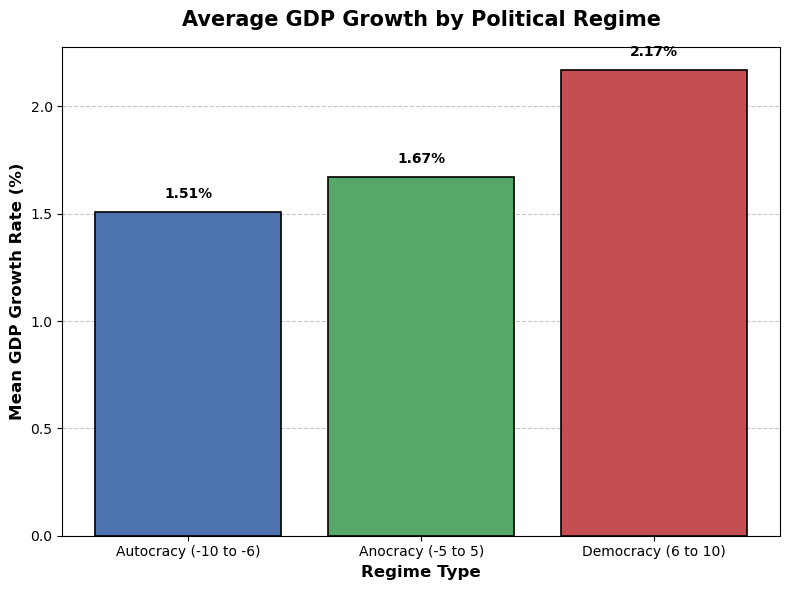

In [49]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE
import matplotlib.pyplot as plt
import numpy as np

print("=== Part 5: Plot 1 (Bar Chart) ===")
plt.figure(figsize=(8, 6))

categories = regime_gdp_stats.index
mean_values = regime_gdp_stats['Mean']

bars = plt.bar(
    categories, 
    mean_values, 
    color=['#4C72B0', '#55A868', '#C44E52'],  
    edgecolor='black',                        
    linewidth=1.2,
    zorder=3
)

plt.title('Average GDP Growth by Political Regime', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Regime Type', fontsize=12, fontweight='bold')
plt.ylabel('Mean GDP Growth Rate (%)', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.05, 
        f'{yval:.2f}%', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


=== Part 5: Plot 2 (Scatter Plot) ===


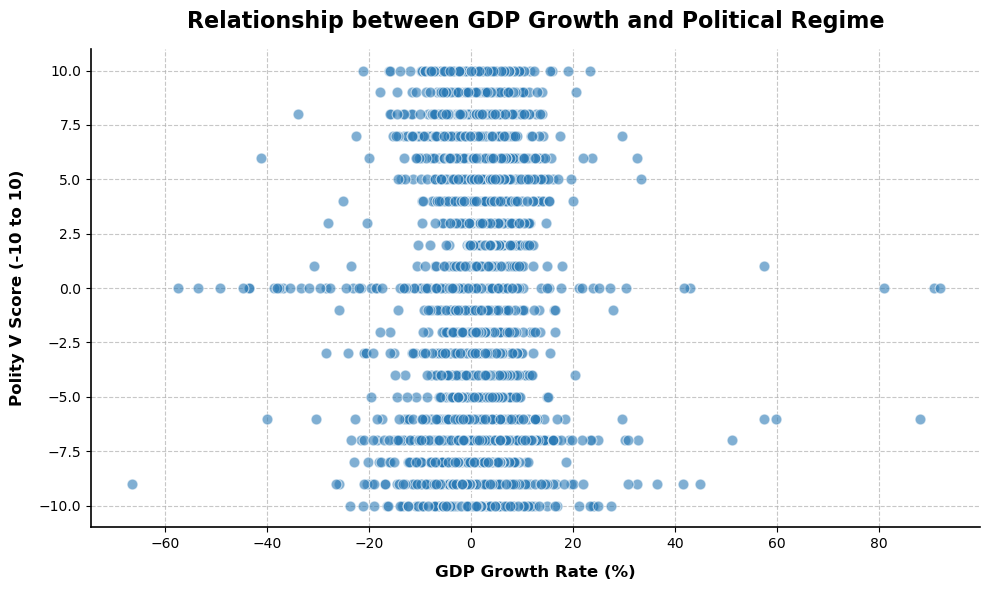

In [50]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE
import matplotlib.pyplot as plt

print("=== Part 5: Plot 2 (Scatter Plot) ===")

plt.figure(figsize=(10, 6), facecolor='white')

plt.scatter(
    final_cleaned_data['gdp_growth'], 
    final_cleaned_data['polity2'], 
    color='#2c7bb6',     
    alpha=0.6,             
    edgecolor='w',        
    linewidth=0.8,       
    s=60,                  
    marker='o',           
    zorder=3                
)

plt.title('Relationship between GDP Growth and Political Regime', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('GDP Growth Rate (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Polity V Score (-10 to 10)', fontsize=12, fontweight='bold', labelpad=10)

plt.grid(True, linestyle='--', alpha=0.7, zorder=0)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

plt.tight_layout()
plt.show()

=== Part 5: Exploratory Modeling (Standard Alignment) ===
--- Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                polity2   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     17.89
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.38e-05
Time:                        22:51:19   Log-Likelihood:                -20756.
No. Observations:                6123   AIC:                         4.152e+04
Df Residuals:                    6121   BIC:                         4.153e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

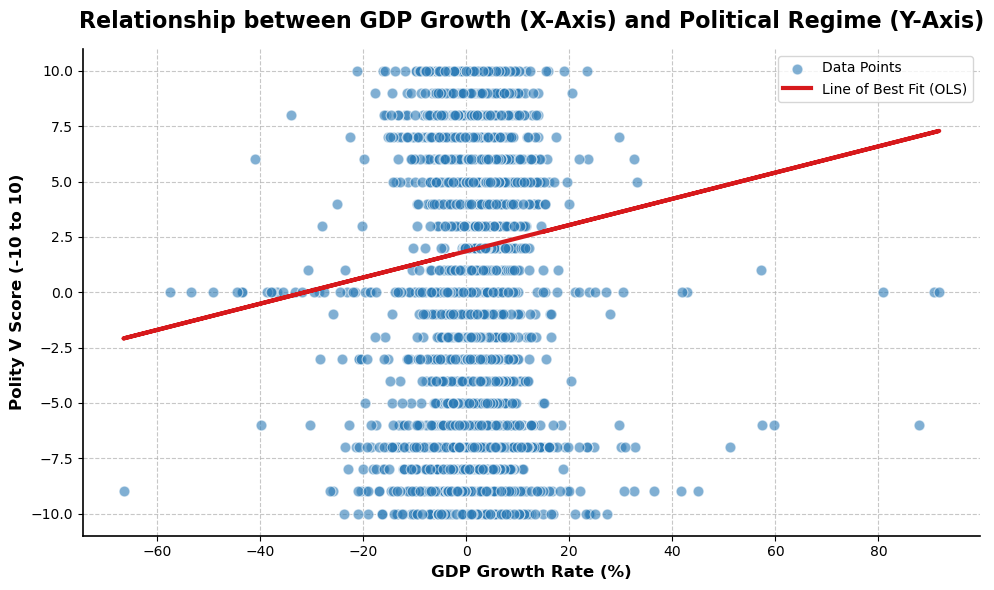

In [57]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE
import matplotlib.pyplot as plt
import statsmodels.api as sm

print("=== Part 5: Exploratory Modeling (Standard Alignment) ===")

X = final_cleaned_data['gdp_growth']
y = final_cleaned_data['polity2']

X_with_const = sm.add_constant(X)

model = sm.OLS(y, X_with_const)
results = model.fit()

print("--- Regression Summary ---")
print(results.summary())
print("\n")

plt.figure(figsize=(10, 6), facecolor='white')

plt.scatter(X, y, color='#2c7bb6', alpha=0.6, edgecolor='w', linewidth=0.8, s=60, label='Data Points', zorder=2)

plt.plot(X, results.predict(X_with_const), color='#d7191c', linewidth=3, label='Line of Best Fit (OLS)', zorder=3)

plt.title('Relationship between GDP Growth (X-Axis) and Political Regime (Y-Axis)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('GDP Growth Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Polity V Score (-10 to 10)', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7, zorder=1)
plt.legend(loc='best')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)

plt.tight_layout()
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

In [ ]:
#Plot 1 shows the average GDP growth rate of each regime type.
#Plot 2 shows the distribution of GDP growth rates according to the polity 5 scores.
#Plot 3 is the regression analysis of how much the gdp growth rate explains the political regime.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.